# Lab 06 — Build a Synthetic Wordle Curriculum (v2)

**Goal:** turn the symbolic expert from Lab 05 into a leakage-safe supervised dataset for Qwen3-0.6B.

This version fixes an important dataset issue discovered during the first pass:

> Answer-level splitting alone does not prevent leakage when different hidden answers generate the exact same observable prompt.

So this notebook enforces **two levels of isolation**:

1. split by hidden answer before generating examples;
2. deduplicate exact model-facing prompts across splits, with held-out splits taking priority over train.

The curriculum still has three supervision families:

- `NEXT_GUESS`
- `VALID_CANDIDATE`
- `CHOOSE_VALID`

In [1]:
from __future__ import annotations

from collections import Counter
from dataclasses import dataclass
from pathlib import Path
import hashlib
import json
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from tiny_wordle.game import Turn, score_string
from tiny_wordle.expert import EntropyExpert

DATA_DIR = Path("../data")
GENERATED_DIR = DATA_DIR / "generated"
GENERATED_DIR.mkdir(parents=True, exist_ok=True)

ANSWERS = [
    line.strip().upper()
    for line in (DATA_DIR / "wordle-answers-original.txt").read_text().splitlines()
    if line.strip()
]

PATTERNS = np.load(DATA_DIR / "wordle-patterns-original-2315.npy")

assert len(ANSWERS) == 2315
assert PATTERNS.shape == (2315, 2315)

expert = EntropyExpert(ANSWERS, PATTERNS)
WORD_TO_INDEX = expert.word_to_index
ALL_INDICES = expert.all_indices

print("answers:", len(ANSWERS))
print("pattern matrix:", PATTERNS.shape, PATTERNS.dtype)

answers: 2315
pattern matrix: (2315, 2315) uint8


## 6.1 Freeze answer-level splits

`PLANT` is a dev/smoke answer because we used it while tuning the Lab 04 harness.

The remaining fixed Lab 04 answers stay test-only.

In [3]:
DEV_FIXED = {"PLANT"}

TEST_FIXED = {
    "SHORE", "MIGHT", "BRICK", "GHOST", "KNIFE",
    "DOUBT", "FLING", "ROUND", "CHAMP", "WASTE",
    "BLIND", "POINT", "SLATE", "CRANE", "APPLE",
    "SHEEP", "BANAL", "ALLEY", "AUDIO",
}

assert DEV_FIXED.isdisjoint(TEST_FIXED)
assert DEV_FIXED <= set(ANSWERS)
assert TEST_FIXED <= set(ANSWERS)

def stable_bucket(word: str) -> int:
    digest = hashlib.sha256(word.encode("utf-8")).digest()
    return int.from_bytes(digest[:8], "big") % 1000

def answer_split(answer: str) -> str:
    if answer in TEST_FIXED:
        return "test"
    if answer in DEV_FIXED:
        return "dev"
    return "dev" if stable_bucket(answer) < 100 else "train"

split_counts = Counter(answer_split(word) for word in ANSWERS)
print(split_counts)

Counter({'train': 2065, 'dev': 231, 'test': 19})


## 6.2 Recreate expert states

In [4]:
@dataclass
class ExpertState:
    answer: str
    split: str
    turn: int
    history: list[Turn]
    candidate_indices: list[int]
    expert_guess: str
    expert_entropy: float

def play_expert_states(answer: str, max_turns: int = 6):
    answer = answer.upper()
    candidate_indices = ALL_INDICES.copy()
    history: list[Turn] = []
    states: list[ExpertState] = []
    solved = False

    for turn in range(1, max_turns + 1):
        guess_idx = expert.choose(candidate_indices)
        guess = ANSWERS[guess_idx]
        entropy = expert.entropy(guess_idx, candidate_indices)

        states.append(
            ExpertState(
                answer=answer,
                split=answer_split(answer),
                turn=turn,
                history=list(history),
                candidate_indices=candidate_indices.tolist(),
                expert_guess=guess,
                expert_entropy=entropy,
            )
        )

        feedback = score_string(answer, guess)
        history.append(Turn(guess=guess, feedback=feedback))

        if feedback == "GGGGG":
            solved = True
            break

        candidate_indices = expert.update(candidate_indices, guess_idx, feedback)

        if len(candidate_indices) == 0:
            raise RuntimeError(f"candidate set became empty for {answer}")

    return states, solved

In [5]:
all_states: list[ExpertState] = []
solved_by_answer = {}

for answer in ANSWERS:
    states, solved = play_expert_states(answer)
    all_states.extend(states)
    solved_by_answer[answer] = solved

print("expert states:", len(all_states))
print("solved answers:", sum(solved_by_answer.values()))
print("failed answers:", sum(not x for x in solved_by_answer.values()))

expert states: 8319
solved answers: 2304
failed answers: 11


## 6.3 Model-facing history format

In [6]:
def format_history(history: list[Turn]) -> str:
    if not history:
        return "No previous guesses."

    return "\n".join(
        f"{' '.join(turn.guess)} -> {' '.join(turn.feedback)}"
        for turn in history
    )

## 6.4 Task generators

In [7]:
def make_next_guess_example(state: ExpertState) -> dict | None:
    if not solved_by_answer[state.answer]:
        return None

    prompt = (
        "Task: NEXT_GUESS\n"
        "You are playing Wordle.\n"
        "Use the game history to choose the next guess.\n"
        "Return exactly one uppercase five-letter word.\n\n"
        "History:\n"
        f"{format_history(state.history)}"
    )

    return {
        "task": "NEXT_GUESS",
        "split": state.split,
        "answer": state.answer,
        "turn": state.turn,
        "candidate_count": len(state.candidate_indices),
        "prompt": prompt,
        "response": state.expert_guess,
    }

In [8]:
RNG = random.Random(42)

def sample_positive_negative(state: ExpertState):
    valid = state.candidate_indices
    valid_set = set(valid)

    positive_idx = RNG.choice(valid)

    while True:
        negative_idx = RNG.randrange(len(ANSWERS))
        if negative_idx not in valid_set:
            break

    return ANSWERS[positive_idx], ANSWERS[negative_idx]

def make_validity_example(state: ExpertState, candidate: str, is_valid: bool) -> dict:
    prompt = (
        "Task: VALID_CANDIDATE\n"
        "You are playing Wordle.\n"
        "Given the game history, decide whether the candidate "
        "could still be the hidden answer.\n"
        "Return exactly VALID or INVALID.\n\n"
        "History:\n"
        f"{format_history(state.history)}\n\n"
        f"Candidate: {' '.join(candidate)}"
    )

    return {
        "task": "VALID_CANDIDATE",
        "split": state.split,
        "answer": state.answer,
        "turn": state.turn,
        "candidate_count": len(state.candidate_indices),
        "candidate": candidate,
        "prompt": prompt,
        "response": "VALID" if is_valid else "INVALID",
    }

In [9]:
def make_choose_valid_example(state: ExpertState) -> dict | None:
    if state.turn == 1:
        return None

    positive, negative = sample_positive_negative(state)
    positive_first = stable_bucket(state.answer + str(state.turn)) % 2 == 0

    if positive_first:
        option_a, option_b = positive, negative
    else:
        option_a, option_b = negative, positive

    prompt = (
        "Task: CHOOSE_VALID\n"
        "You are playing Wordle.\n"
        "Exactly one option is consistent with all previous feedback.\n"
        "Return exactly the valid five-letter word.\n\n"
        "History:\n"
        f"{format_history(state.history)}\n\n"
        f"Option A: {' '.join(option_a)}\n"
        f"Option B: {' '.join(option_b)}"
    )

    return {
        "task": "CHOOSE_VALID",
        "split": state.split,
        "answer": state.answer,
        "turn": state.turn,
        "candidate_count": len(state.candidate_indices),
        "prompt": prompt,
        "response": positive,
    }

## 6.5 Build raw curriculum

In [11]:
raw_examples = []
opening_kept = set()

for state in all_states:
    next_example = make_next_guess_example(state)

    if next_example is not None:
        if state.turn == 1:
            if state.split not in opening_kept:
                raw_examples.append(next_example)
                opening_kept.add(state.split)
        else:
            raw_examples.append(next_example)

    if state.turn > 1:
        positive, negative = sample_positive_negative(state)

        raw_examples.append(make_validity_example(state, positive, True))
        raw_examples.append(make_validity_example(state, negative, False))

        choose = make_choose_valid_example(state)
        if choose is not None:
            raw_examples.append(choose)

print("raw examples:", len(raw_examples))

raw examples: 23964


## 6.6 Cross-split deduplication with held-out priority

If the exact same `(prompt, response)` occurs in multiple answer-level splits:

```text
test > dev > train
```

The held-out copy wins and the training copy is removed.

In [12]:
split_priority = {
    "train": 0,
    "dev": 1,
    "test": 2,
}

dedup = {}

for ex in raw_examples:
    key = (ex["prompt"], ex["response"])
    existing = dedup.get(key)

    if (
        existing is None
        or split_priority[ex["split"]] > split_priority[existing["split"]]
    ):
        dedup[key] = ex

examples = list(dedup.values())

print("deduplicated examples:", len(examples))

deduplicated examples: 18824


## 6.7 Detect ambiguous prompts

If the same exact prompt has different targets, the task construction is ambiguous and we should not train on it.

In [13]:
prompt_targets = {}

for ex in examples:
    prompt_targets.setdefault(ex["prompt"], set()).add(ex["response"])

ambiguous = {
    prompt: targets
    for prompt, targets in prompt_targets.items()
    if len(targets) > 1
}

print("ambiguous prompts:", len(ambiguous))

if ambiguous:
    for prompt, targets in list(ambiguous.items())[:10]:
        print("=" * 80)
        print(prompt)
        print("targets:", targets)

assert not ambiguous, (
    "Same model-facing prompt has conflicting targets. "
    "Inspect ambiguity before training."
)

ambiguous prompts: 0


## 6.8 Assert no prompt crosses splits

In [14]:
df = pd.DataFrame(examples)

prompt_splits = (
    df[["prompt", "split"]]
    .drop_duplicates()
    .groupby("prompt")["split"]
    .nunique()
)

assert prompt_splits.max() == 1

print("No model-facing prompt appears in multiple splits.")

No model-facing prompt appears in multiple splits.


## 6.9 Inspect distribution

In [15]:
print("TASK COUNTS")
print(df["task"].value_counts())

print("\nSPLIT COUNTS")
print(df["split"].value_counts())

print("\nTASK × SPLIT")
print(pd.crosstab(df["task"], df["split"]))

print("\nTURN DISTRIBUTION")
print(pd.crosstab(df["turn"], df["task"]))

TASK COUNTS
task
VALID_CANDIDATE    10516
CHOOSE_VALID        6004
NEXT_GUESS          2304
Name: count, dtype: int64

SPLIT COUNTS
split
train    16465
dev       2169
test       190
Name: count, dtype: int64

TASK × SPLIT
split             dev  test  train
task                              
CHOOSE_VALID      602    49   5353
NEXT_GUESS        385    43   1876
VALID_CANDIDATE  1182    98   9236

TURN DISTRIBUTION
task  CHOOSE_VALID  NEXT_GUESS  VALID_CANDIDATE
turn                                           
1                0           1                0
2             2314         131             3780
3             2183         999             3861
4             1184         919             2262
5              265         207              501
6               58          47              112


In [16]:
df.groupby("task")["candidate_count"].describe()

,count,mean,std,min,25%,50%,75%,max
task,,,,,,,,
CHOOSE_VALID,6004.0,25.595603,40.780308,1.0,1.0,4.0,26.0,168.0
NEXT_GUESS,2304.0,3.610677,48.792914,1.0,1.0,1.0,2.0,2315.0
VALID_CANDIDATE,10516.0,23.655287,39.557074,1.0,1.0,4.0,25.0,168.0


## 6.10 Answer-level split integrity

In [17]:
answer_splits = (
    df[["answer", "split"]]
    .drop_duplicates()
    .groupby("answer")["split"]
    .nunique()
)

assert answer_splits.max() == 1

train_answers = set(df.loc[df["split"] == "train", "answer"])
dev_answers = set(df.loc[df["split"] == "dev", "answer"])
test_answers = set(df.loc[df["split"] == "test", "answer"])

assert train_answers.isdisjoint(dev_answers)
assert train_answers.isdisjoint(test_answers)
assert dev_answers.isdisjoint(test_answers)

assert TEST_FIXED <= test_answers

print("train answers:", len(train_answers))
print("dev answers:", len(dev_answers))
print("test answers:", len(test_answers))
print("answer-level split integrity passed.")

train answers: 2064
dev answers: 231
test answers: 19
answer-level split integrity passed.


## 6.11 Mechanical label validation

In [18]:
state_lookup = {(s.answer, s.turn): s for s in all_states}
checked = 0

for ex in examples:
    state = state_lookup[(ex["answer"], ex["turn"])]

    if ex["task"] == "VALID_CANDIDATE":
        idx = WORD_TO_INDEX[ex["candidate"]]
        actually_valid = idx in set(state.candidate_indices)
        expected = "VALID" if actually_valid else "INVALID"
        assert ex["response"] == expected

    elif ex["task"] == "NEXT_GUESS":
        assert ex["response"] == state.expert_guess
        assert len(ex["response"]) == 5

    elif ex["task"] == "CHOOSE_VALID":
        idx = WORD_TO_INDEX[ex["response"]]
        assert idx in set(state.candidate_indices)

    checked += 1

print("mechanically validated examples:", checked)

mechanically validated examples: 18824


## 6.12 Inspect random examples

In [19]:
sample = df.sample(6, random_state=42)

for _, row in sample.iterrows():
    print("=" * 80)
    print("TASK:", row["task"])
    print("SPLIT:", row["split"])
    print("ANSWER METADATA:", row["answer"])
    print(row["prompt"])
    print("\nTARGET:", row["response"])

TASK: NEXT_GUESS
SPLIT: train
ANSWER METADATA: KARMA
Task: NEXT_GUESS
You are playing Wordle.
Use the game history to choose the next guess.
Return exactly one uppercase five-letter word.

History:
R A I S E -> Y G B B B
P A R T Y -> B G G B B
C A R O L -> B G G B B

TARGET: KARMA
TASK: VALID_CANDIDATE
SPLIT: train
ANSWER METADATA: CAUSE
Task: VALID_CANDIDATE
You are playing Wordle.
Given the game history, decide whether the candidate could still be the hidden answer.
Return exactly VALID or INVALID.

History:
R A I S E -> B G B G G

Candidate: C H A I R

TARGET: INVALID
TASK: CHOOSE_VALID
SPLIT: train
ANSWER METADATA: ALIVE
Task: CHOOSE_VALID
You are playing Wordle.
Exactly one option is consistent with all previous feedback.
Return exactly the valid five-letter word.

History:
R A I S E -> B Y G B G

Option A: A B I D E
Option B: O V A T E

TARGET: ABIDE
TASK: NEXT_GUESS
SPLIT: dev
ANSWER METADATA: ILIAC
Task: NEXT_GUESS
You are playing Wordle.
Use the game history to choose the next

## 6.13 Token-length inspection

In [20]:
from transformers import AutoTokenizer

MODEL_ID = "Qwen/Qwen3-0.6B"
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

def formatted_training_text(prompt: str, response: str) -> str:
    messages = [
        {"role": "user", "content": prompt},
        {"role": "assistant", "content": response},
    ]

    return tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=False,
        enable_thinking=False,
    )

token_lengths = []

for ex in examples:
    text = formatted_training_text(ex["prompt"], ex["response"])
    token_lengths.append(
        len(tokenizer.encode(text, add_special_tokens=False))
    )

df["token_length"] = token_lengths

print(df["token_length"].describe(
    percentiles=[0.5, 0.9, 0.95, 0.99]
))

count    18824.000000
mean        84.713185
std         11.324495
min         53.000000
50%         84.000000
90%        101.000000
95%        108.000000
99%        114.000000
max        126.000000
Name: token_length, dtype: float64


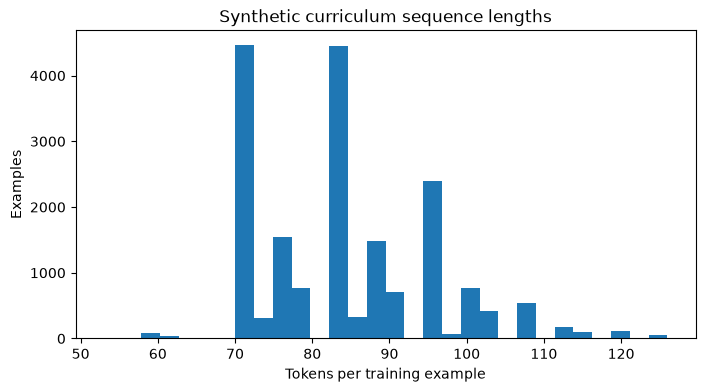

In [21]:
plt.figure(figsize=(8, 4))
plt.hist(df["token_length"], bins=30)
plt.xlabel("Tokens per training example")
plt.ylabel("Examples")
plt.title("Synthetic curriculum sequence lengths")
plt.show()

## 6.14 Difficulty distribution

In [22]:
def difficulty(candidate_count: int) -> str:
    if candidate_count <= 2:
        return "1-2"
    if candidate_count <= 10:
        return "3-10"
    if candidate_count <= 50:
        return "11-50"
    if candidate_count <= 200:
        return "51-200"
    return "201+"

df["difficulty"] = df["candidate_count"].map(difficulty)
print(pd.crosstab(df["difficulty"], df["task"]))

task        CHOOSE_VALID  NEXT_GUESS  VALID_CANDIDATE
difficulty                                           
1-2                 2271        1902             4376
11-50               1143          55             1871
201+                   0           1                0
3-10                1467         334             2469
51-200              1123          12             1800


## 6.15 Save JSONL splits

In [23]:
OUTPUT_COLUMNS = [
    "task",
    "split",
    "answer",
    "turn",
    "candidate_count",
    "prompt",
    "response",
]

paths = {}

for split in ["train", "dev", "test"]:
    split_df = df.loc[df["split"] == split, OUTPUT_COLUMNS].copy()
    path = GENERATED_DIR / f"wordle-sft-{split}.jsonl"

    split_df.to_json(
        path,
        orient="records",
        lines=True,
        force_ascii=False,
    )

    paths[split] = path

    print(
        split,
        len(split_df),
        "->",
        path,
        f"({path.stat().st_size / 1024:.1f} KiB)",
    )

train 16465 -> ../data/generated/wordle-sft-train.jsonl (5894.3 KiB)
dev 2169 -> ../data/generated/wordle-sft-dev.jsonl (763.4 KiB)
test 190 -> ../data/generated/wordle-sft-test.jsonl (65.9 KiB)


## 6.16 Reload persisted artifacts with Hugging Face Datasets

In [24]:
from datasets import load_dataset

dataset = load_dataset(
    "json",
    data_files={
        "train": str(paths["train"]),
        "validation": str(paths["dev"]),
        "test": str(paths["test"]),
    },
)

print(dataset)

for split in dataset:
    print(split, dataset[split].num_rows)

print("\ncolumns:", dataset["train"].column_names)
print("\nfirst train row:")
print(dataset["train"][0])

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['task', 'split', 'answer', 'turn', 'candidate_count', 'prompt', 'response'],
        num_rows: 16465
    })
    validation: Dataset({
        features: ['task', 'split', 'answer', 'turn', 'candidate_count', 'prompt', 'response'],
        num_rows: 2169
    })
    test: Dataset({
        features: ['task', 'split', 'answer', 'turn', 'candidate_count', 'prompt', 'response'],
        num_rows: 190
    })
})
train 16465
validation 2169
test 190

columns: ['task', 'split', 'answer', 'turn', 'candidate_count', 'prompt', 'response']

first train row:
{'task': 'VALID_CANDIDATE', 'split': 'train', 'answer': 'ABACK', 'turn': 2, 'candidate_count': 92, 'prompt': 'Task: VALID_CANDIDATE\nYou are playing Wordle.\nGiven the game history, decide whether the candidate could still be the hidden answer.\nReturn exactly VALID or INVALID.\n\nHistory:\nR A I S E -> B Y B B B\n\nCandidate: A L O N G', 'response': 'VALID'}


## 6.17 Write the manifest

In [25]:
manifest = {
    "version": 2,
    "generator": "Lab 06 synthetic Wordle curriculum v2",
    "answer_lexicon": "original Wordle 2315 answers",
    "expert": "candidate-only maximum Shannon entropy",
    "expert_solve_rate_lab05": 2304 / 2315,
    "representation": "space-separated letters and B/Y/G feedback",
    "tasks": ["NEXT_GUESS", "VALID_CANDIDATE", "CHOOSE_VALID"],
    "next_guess_policy": (
        "exclude action examples from expert trajectories "
        "that fail within six turns"
    ),
    "split_policy": (
        "answer-level split before generation, then exact model-facing "
        "prompt/response dedup across splits with test > dev > train priority"
    ),
    "fixed_dev_answers": sorted(DEV_FIXED),
    "fixed_test_answers": sorted(TEST_FIXED),
    "counts": {
        split: int((df["split"] == split).sum())
        for split in ["train", "dev", "test"]
    },
    "task_counts": {
        key: int(value)
        for key, value in df["task"].value_counts().items()
    },
    "ambiguous_prompt_count": len(ambiguous),
}

manifest_path = GENERATED_DIR / "wordle-sft-manifest.json"
manifest_path.write_text(json.dumps(manifest, indent=2))

print(manifest_path)
print(json.dumps(manifest, indent=2))

../data/generated/wordle-sft-manifest.json
{
  "version": 2,
  "generator": "Lab 06 synthetic Wordle curriculum v2",
  "answer_lexicon": "original Wordle 2315 answers",
  "expert": "candidate-only maximum Shannon entropy",
  "expert_solve_rate_lab05": 0.9952483801295896,
  "representation": "space-separated letters and B/Y/G feedback",
  "tasks": [
    "NEXT_GUESS",
    "VALID_CANDIDATE",
    "CHOOSE_VALID"
  ],
  "next_guess_policy": "exclude action examples from expert trajectories that fail within six turns",
  "split_policy": "answer-level split before generation, then exact model-facing prompt/response dedup across splits with test > dev > train priority",
  "fixed_dev_answers": [
    "PLANT"
  ],
  "fixed_test_answers": [
    "ALLEY",
    "APPLE",
    "AUDIO",
    "BANAL",
    "BLIND",
    "BRICK",
    "CHAMP",
    "CRANE",
    "DOUBT",
    "FLING",
    "GHOST",
    "KNIFE",
    "MIGHT",
    "POINT",
    "ROUND",
    "SHEEP",
    "SHORE",
    "SLATE",
    "WASTE"
  ],
  "counts":

# Lab 06 v2 checkpoint

Send me:

- answer split counts;
- expert state count;
- raw example count;
- deduplicated example count;
- `ambiguous prompts`;
- the `No model-facing prompt appears in multiple splits.` result;
- task counts;
- split counts;
- answer-level split integrity result;
- mechanically validated example count;
- token-length statistics;
- saved JSONL row counts;
- Hugging Face Dataset split sizes.

If those are clean, Lab 07 can finally train on a dataset whose boundaries we actually trust.